In [1]:
from pydantic import BaseModel

In [2]:

class user(BaseModel):
    name: str
    age: int

user1 = user(name="soura", age= 1.0)
print(user1)
print(type(user1.age))

name='soura' age=1
<class 'int'>


In [3]:
from typing import TypedDict

class State(TypedDict):
    graph_info : str

In [24]:
def start_play(xyz : State):
    print("start paly node has benn called")
    return {"graph_info" : xyz["graph_info"] + " i plannig to paly"}

def cricket(state : State):
    print("cricket node has been called")
    return {"graph_info" : state["graph_info"] + " i plannig to watch cricket"}

def football(state : State):
    print("football node has been called")
    return {"graph_info" : state["graph_info"] + " i plannig to watch football"}

def volleyball(state : State):
    print("volleyball node has been called")
    return {"graph_info" : state["graph_info"] + " i plannig to watch volleyball"}

In [5]:
import random
random.random()

0.5364502187906603

In [25]:
import random
from typing import Literal

def random_sport(state : State) -> Literal["cricket", "football", "volleyball"]:
    print("random sport node has been called")
    
    num = random.random()
    if(num < 0.33):
        return "cricket"
    elif(num < 0.66):
        return "football"
    else:
        return "volleyball"

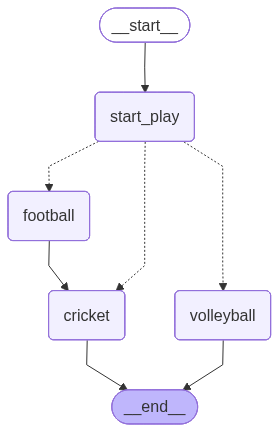

In [45]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(State)

graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("football", football)
graph.add_node("volleyball", volleyball)


graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_sport)
graph.add_edge("cricket", END)
graph.add_edge("football", "cricket")
graph.add_edge("volleyball", END)
graph.add_edge("football", END)

graph_builder = graph.compile()

png = graph_builder.get_graph(xray=True).draw_mermaid_png()
display(Image(png))

In [46]:
graph_builder.invoke({
    "graph_info": "Today"
})

start paly node has benn called
random sport node has been called
cricket node has been called


{'graph_info': 'Today i plannig to paly i plannig to watch cricket'}